# Explicación de la fórmula Compression Effectiveness Score

## Fórmula

$$
\text{CES}\text{(x)} = w_a \cdot \left( e^{-k \cdot \left(1 - \frac{A_c}{A_b}\right)} - 1 \right) + w_r \cdot \left( \frac{Sz_b - Sz_c}{Sz_b} + \frac{L_b - L_c}{L_b} \right)
$$


Esta fórmula calcula el **Compression Effectiveness Score (CES)** comparando un modelo comprimido con su versión original en FP32. Considera tres cosas:

- **Precisión** (accuracy)
- **Tamaño del modelo**
- **Latencia de inferencia**

Y se puede expandir para usar más términos de recursos usados (RAM, Energía en Watts, etc.). La idea es saber si vale la pena comprimir el modelo.

### 1. *Accuracy term*:

$$
w_a \cdot \left( e^{-k \cdot \left(1 - \frac{A_c}{A_b} \right)} - 1 \right)
$$

- \( $A_c$ \): precisión del modelo comprimido (int4, int8, fp16)  
- \( $A_b$ \): precisión del modelo base (FP32)  
- \( $k$ \): qué tan fuerte penaliza perder precisión  
- \( $w_a$ \): cuánto te importa la precisión (por ejemplo, 0.9)

- Si el modelo comprimido tiene accuracy similar, es decir, un valor cercano a 0 (¡bien!)
- Si pierde un poco de su performance entonces se aplica una penalización suave pero si se pierde mucha precisión se aplica una penalización fuerte (exponencial)
- El `-1` asegura que el modelo base (FP32) tenga CES = 0

---

### 2. *Resource term*:

$$
w_r \cdot \left( \frac{Sz_b - Sz_c}{Sz_b} + \frac{L_b - L_c}{L_b} \right)
$$

- \( $Sz$ \): tamaño del modelo  
- \( $L$ \): latencia (tiempo de inferencia)  
- \( $w_r$ \): cuánto te importan los recursos (por ejemplo, 0.6)

- Mide cuánto **más pequeño y más rápido** es el modelo comprimido con respecto al modelo base.
- Si el modelo es igual de pesado y lento que el original, entonces, este término vale 0. Si mejora en tamaño y velocidad, entonces, se suma puntos al CES

---

## Intepretacion y definicion en situaciones reales

| CES | Significado |
|------------|-------------|
| **> 0**    | El modelo comprimido **vale la pena** (es más eficiente y mantiene buena precisión) |
| **= 0**    | Igual que el modelo base FP32 |
| **< 0**    | El modelo comprimido **no conviene** (perdió precisión o no ganó eficiencia) |

---

In [55]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import re

In [56]:
linear_metrics = ["accuracy", "precision",  "recall", "auc"]
boxplot_metrics = ["cross_entropy_loss", "mae_loss", "mse_loss"]
barplot_metrics = ["f1_score", "r2_score", "latency", "max_malloc", "size"]

In [57]:
def load_metrics_csv(split, comp_method, mode):
    # to store all dfs from the csv files
    dfs = []

    models = ["mobilenetv2", "resnet18", "densenet121", "vgg16", "vit-tiny",
               "efficientnet-b0", "shufflenetv2-0.5x", "regnety-400mf",
               "mnasnet0_5", "convnext-tiny", "ghostnetv2", "tinynet-a"]

    precision = ["fp32","fp16","int8","int4"]

    # Load data from all CSVs
    for model in models:
        for bw in precision:
            # Load CSV in individual dataframe
            path = f"metrics/pytorch/{comp_method.lower()}/{split}_metrics_{model}_{comp_method.upper()}_{mode.upper()}.csv"
            csv_file = glob.glob(path)
            
            df = pd.read_csv(csv_file[0])

            
            # Append to the list of dataframes for all models
        dfs.append(df)

    # Concatenate all data into a single DataFrame
    dfs_all = pd.concat(dfs, ignore_index=True)
    
    return dfs_all

def lineplot(metrics, models, df, mode):
    for metric in metrics:
        # Line plot for each metric
        plt.figure(figsize=(12, 6))
        for model in models:
            # Subset for the specific model and group by 'Epoch' to calculate the mean
            subset = df[df["model"] == model].groupby("epoch")[metric].mean()
            
            # Plot the metric
            plt.plot(subset.index, subset.values, label=model,  linestyle='-')
            print(f"Average & Highest {mode.capitalize()} {metric.capitalize()} for {model}: {subset.mean():4f}, {subset.max():4f}")

        plt.xlabel("Epoch")
        plt.ylabel(metric.capitalize())
        plt.title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        plt.legend()
        plt.show()

def boxplot(metrics, models, df, mode):
    for metric in metrics:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))

        # Boxplot with outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, ax=axes[0])
        axes[0].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models in {mode.capitalize()}")
        axes[0].tick_params(axis='x', rotation=45, labelsize=10)

        # Boxplot without outliers
        sns.boxplot(x="model", y=metric, data=df, order=models, showfliers=False, ax=axes[1])
        axes[1].set_title(f"{metric.capitalize()} Over Epochs Across SOTA-CV Models (Outliers Removed) in {mode.capitalize()}")
        axes[1].tick_params(axis='x', rotation=45, labelsize=10)

        plt.tight_layout()
        plt.show()

def barplot(metrics, models, df, mode):
    for metric in metrics:
        if (metric == "latency" or metric == "max_malloc") and mode == "training":
            continue
        elif metric == "size" and mode != "testing":
            continue
        else:
            plt.figure(figsize=(12, 6))
            for model in models:
                # Plot the metric
                sns.barplot(x="model", y=metric, data=df, order=models, errorbar="sd")
            plt.xticks(rotation=45, ha='right')
            plt.title(f"{metric.capitalize()} over Epochs Across SOTA-CV Models in {mode.capitalize()}")
            plt.show()

def extract_float(s):
    match = re.search(r'\d+\.\d+', s)
    return float(match.group()) if match else None

def CES(data):
    w_a = 0.9
    w_r = 0.6
    k = 5  # Sensitivity to accuracy degradation

    res_list = []

    for model in data["model"].unique():
        base = data[(data["model"] == model) & (data["bit-width"] == "fp32")].iloc[0]
        
        A_b = base["accuracy"]
        Sz_b = base["model_size"]
        L_b = base["latency"]
        
        for _, row in data[data["model"] == model].iterrows():
            A_c = row["accuracy"]
            Sz_c = row["model_size"]
            L_c = row["latency"]
            
            if A_b == 0 or Sz_b == 0 or L_b == 0 or Sz_c == 0 or L_c == 0:
                ces = None
            else:
                # Penalized accuracy term (centered at 0)
                acc_score = np.exp(-k * (1 - (A_c / A_b))) - 1

                # Resource gain (relative)
                size_gain = (Sz_b - Sz_c) / Sz_b
                latency_gain = (L_b - L_c) / L_b

                res = w_a * acc_score + w_r * (size_gain + latency_gain)
            
            res_list.append({
                "model": model,
                "bit-width": row["bit-width"],
                "accuracy": row["accuracy"],
                "model_size": row["model_size"],
                "latency": row["latency"],
                "CES": res
            })

    df = pd.DataFrame(res_list)
    return df


In [58]:
dfs_infer_ptq = load_metrics_csv("testing", "quantization", "ptq")
dfs_infer_ptq['model_size'] = dfs_infer_ptq['model_size'].apply(extract_float)
dfs_infer_ptq['size_to_accuracy'] = dfs_infer_ptq['accuracy']/dfs_infer_ptq['model_size']*100
dfs_infer_ptq['latency_to_accuracy'] = dfs_infer_ptq['accuracy']/dfs_infer_ptq['latency']*100

display(dfs_infer_ptq)

,model,bit-width,model_size,total_loss,cross_entropy_loss,accuracy,precision,recall,f1_score,auc,r2_score,mae_loss,mse_loss,latency,malloc_before,malloc_after,max_malloc,size_to_accuracy,latency_to_accuracy
0,mobilenetv2,fp32,9.78,2.107073,0.424507,0.795775,0.811268,0.795775,0.793520,0.0,-0.034820,1.975531,6.033060,213.731172,0.0,0.0,0.0,8.136755,0.372325
1,mobilenetv2,fp16,4.94,2.105078,0.422461,0.795775,0.811268,0.795775,0.793520,0.0,-0.034235,1.975195,6.030469,481.353802,0.0,0.0,0.0,16.108799,0.165320
2,mobilenetv2,int8,9.82,2.192289,0.541948,0.746479,0.800824,0.746479,0.758998,0.0,-0.009440,1.977666,6.043082,102.775842,0.0,0.0,0.0,7.601618,0.726317
3,mobilenetv2,int4,10.26,4.218861,3.448860,0.359155,0.375469,0.359155,0.366318,0.0,-0.022110,1.966796,6.015531,79.553208,0.0,0.0,0.0,3.500535,0.451465
4,resnet18,fp32,45.04,2.053102,0.410280,0.830986,0.832201,0.830986,0.826620,0.0,0.015064,1.934186,5.886355,50.497228,0.0,0.0,0.0,1.844995,1.645607
5,resnet18,fp16,22.54,2.052930,0.409912,0.830986,0.832201,0.830986,0.826620,0.0,0.014703,1.934180,5.886719,1517.653101,0.0,0.0,0.0,3.686717,0.054755
6,resnet18,int8,45.06,2.063323,0.424227,0.809859,0.813914,0.809859,0.810467,0.0,0.021732,1.934597,5.887881,65.256172,0.0,0.0,0.0,1.797291,1.241046
7,resnet18,int4,21.44,3.205383,2.003022,0.528169,0.620491,0.528169,0.439368,0.0,-0.094567,1.968360,6.010891,59.550927,0.0,0.0,0.0,2.463475,0.886920
8,densenet121,fp32,28.90,2.031694,0.372776,0.816901,0.818316,0.816901,0.816969,0.0,-0.009183,1.937412,5.902500,193.436826,0.0,0.0,0.0,2.826648,0.422309
9,densenet121,fp16,14.57,2.031055,0.372559,0.809859,0.810593,0.809859,0.809949,0.0,-0.009102,1.937305,5.900781,2354.546826,0.0,0.0,0.0,5.558402,0.034396


## Experimenting with CES

In [59]:
ces_df = CES(dfs_infer_ptq)
ces_df.sort_values("CES", ascending=False)
ces_df.to_csv('ces_results.csv')

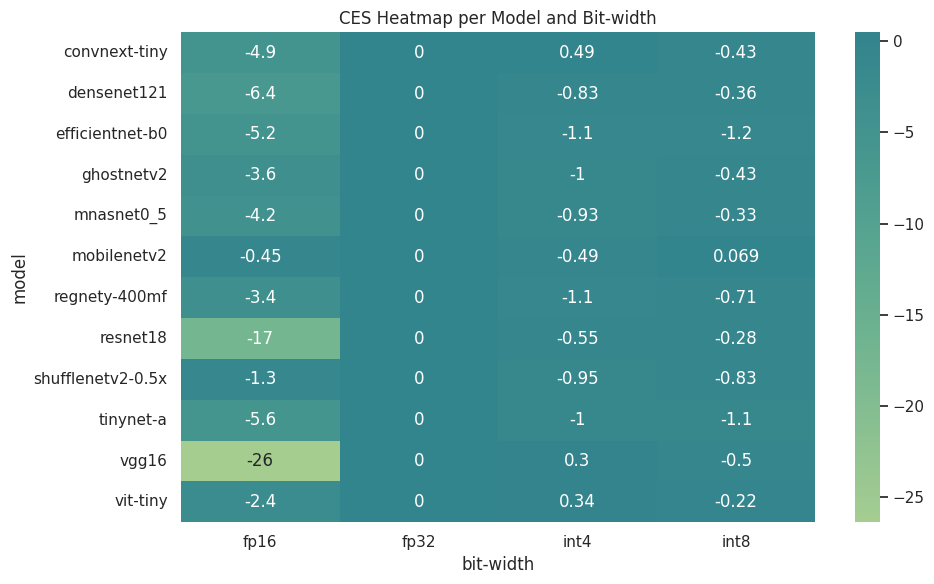

In [60]:
ces_pivot = ces_df.pivot(index="model", columns="bit-width", values="CES", )

plt.figure(figsize=(10, 6))
sns.heatmap(ces_pivot, annot=True, cmap="crest", center=0)
plt.title("CES Heatmap per Model and Bit-width")
plt.tight_layout()

,model,bit-width,accuracy,model_size,latency,CES
15,vgg16,int4,0.816901,29.38,386.273059,0.302249


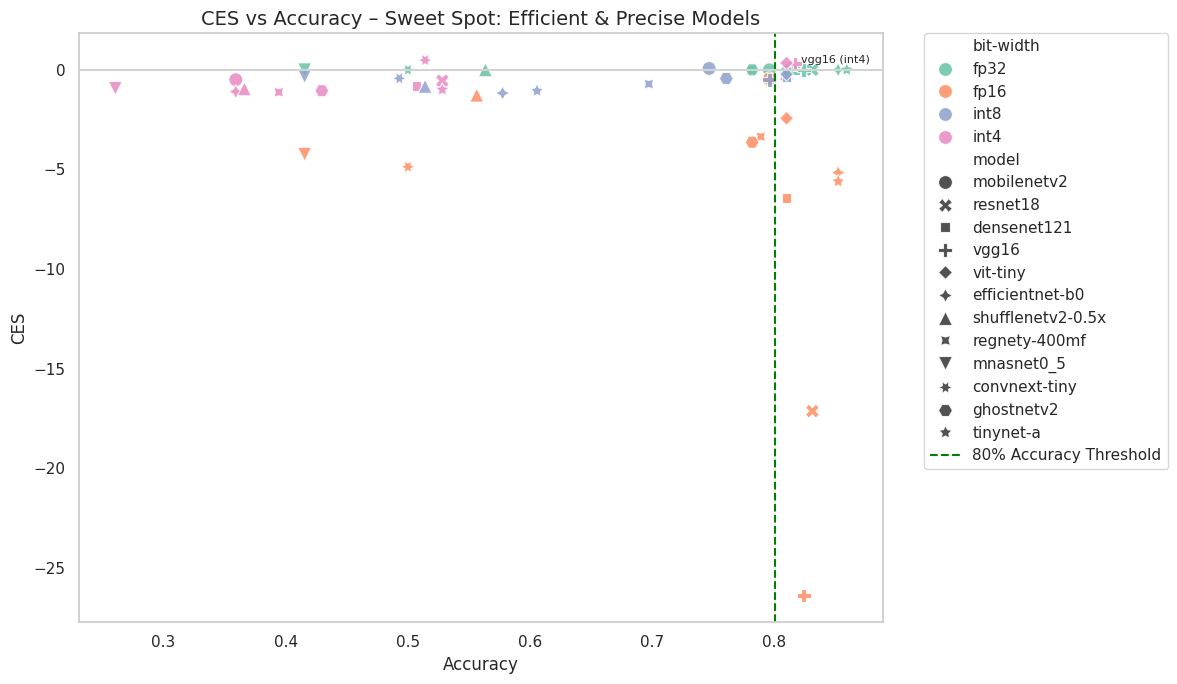

In [61]:
merged = ces_df.copy()  # Or merge with dfs_infer_ptq if you want more columns

plt.figure(figsize=(12, 7))

sns.scatterplot(
    data=merged,
    x="accuracy",
    y="CES",
    hue="bit-width",
    style="model",
    palette="Set2",
    s=100,
    alpha=0.85
)

# Threshold lines
plt.axvline(0.8, color='green', linestyle='--', label='80% Accuracy Threshold')
plt.axhline(0, color='lightgrey', linestyle='-')

# Label top performers
top = merged[(merged["CES"] > 0.0) & (merged["accuracy"] > 0.8)][:-1]
display(top)
for _, row in top.iterrows():
    plt.text(
        row["accuracy"] + 0.005, 
        row["CES"] + 0.05, 
        f"{row['model']} ({row['bit-width']})", 
        fontsize=8
    )

plt.title("CES vs Accuracy – Sweet Spot: Efficient & Precise Models", fontsize=14)
plt.xlabel("Accuracy", fontsize=12)
plt.ylabel("CES", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.grid(False)
plt.tight_layout()
plt.show()